## Analyse des données de produits récupérées par scraping : visualisation des variations de prix

Importation des bibliothèques nécessaires

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from rapidfuzz import fuzz
import seaborn as sns

Cette section importe les bibliothèques nécessaires pour la manipulation de données (pandas), la visualisation (matplotlib, seaborn), le traitement de texte avec des expressions régulières (re) et le calcul de similarité de texte (rapidfuzz).

Fonction : Normalisation du texte

In [2]:
# Function to normalize text
def normalize_text(text):
    if isinstance(text, str):
        text = text.lower()  # Convert to lowercase
        # nom = re.sub(r'[^a-z\s]', '', text)  # Uncomment if needed for special character removal
        return text
    else:
        # Convert non-string inputs to a string or handle them appropriately
        return str(text) if text is not None else ""

Cette fonction standardise le texte en le transformant en minuscules et, si besoin, en supprimant les caractères spéciaux (optionnellement via une ligne commentée).

Fonction : Recherche de noms similaires avec RapidFuzz

In [3]:
# Function to find similar noms using RapidFuzz
def find_similar_noms(nom, nom_list, threshold=70):
    similar_noms = []
    for other_nom in nom_list:
        # Compute similarity score between nom and other nom
        score = fuzz.ratio(nom, other_nom)
        if score >= threshold:
            similar_noms.append((nom, other_nom, score))
    return similar_noms

Cette fonction utilise RapidFuzz pour comparer un nom donné avec une liste de noms en utilisant le token_sort_ratio. Elle retourne une liste de noms similaires dépassant un seuil de similarité spécifié.

Analyse : Variation des prix pour le produit le plus populaire

In [4]:
def analyse_get_top_product_price_variation(df):
    # Normalize product names
    #df['normalized_nom'] = df['nom'].apply(normalize_text)
    #df['normalized_description'] = df['description'].apply(lambda x: normalize_text(x) if pd.notna(x) else "")
    
    #df['nom_and_description'] = df['normalized_nom']+" "+df['normalized_description']
    #df['nom_and_description'] = df['normalized_nom']
    
    # Apply fuzzy matching to group similar product names
    unique_noms = df['nom_and_description'].unique()
    nom_groups = {}

    for nom in unique_noms:
        group = find_similar_noms(nom, unique_noms)
        for _, other_nom, _ in group:
            nom_groups[other_nom] = nom  # Group similar product names

    # Map the grouped noms back to the DataFrame
    df['grouped_nom'] = df['nom_and_description'].map(lambda x: nom_groups.get(x, x))
    
    # Remove duplicates based on product name and website before counting occurrences
    df_unique = df.drop_duplicates(subset=['grouped_nom', 'website'])
    
    # Count the occurrences of each product by website
    product_counts = df_unique.groupby(["grouped_nom", "website"]).size().reset_index(name='count')
    
    # Find the product with the maximum count across all websites
    top_product = product_counts.groupby('grouped_nom').agg({'count': 'sum'}).idxmax().iloc[0]

    # Get the details of that top product across websites
    top_product_data = product_counts[product_counts['grouped_nom'] == top_product]
    
    # Extract price variations for that product across websites
    price_variations = df[df['grouped_nom'] == top_product].drop_duplicates(subset=['website'])[['website', 'prix']]

    return top_product, price_variations.sort_values(by='prix', ascending=True)

Cette fonction :
Normalise les noms et descriptions des produits.
Utilise la similarité textuelle pour regrouper des produits similaires.
Identifie le produit le plus fréquemment répertorié sur les sites web.
Retourne les variations de prix pour ce produit parmi les différents sites.

Visualisation : Variations de prix par site

In [5]:
def visualisation_plot_price_variations(price_variations, product_name):
    # Visualize price variations by website
    plt.figure(figsize=(10, 6))
    plt.bar(price_variations['website'], price_variations['prix'], color='skyblue')
    plt.title(f"Price Variations for {product_name} Across Websites")
    plt.xlabel('Website')
    plt.ylabel('Price (USD)')
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Crée un graphique à barres montrant les variations de prix pour un produit donné sur différents sites.

Analyse : Promotions par catégorie

In [6]:
# Analyze data
def analyse_promotions_par_categorie(df):
    # Filter products on promotion
    promotion_df = df[df['promotion'] != ""]

    # Count promotions by category
    promotions_par_categorie = promotion_df.groupby(['category', 'promotion'])['promotion'].size().reset_index(name="count")

    # Sort by 'count' in descending order and get the top
    top_promotions = promotions_par_categorie.sort_values(by='count', ascending=False).head(10).sort_values(by='count', ascending=True)

    return top_promotions

Cette fonction identifie et compte les promotions appliquées à différents produits selon leurs catégories. Elle retourne les meilleures catégories avec des promotions, triées par fréquence.

Visualisation : Promotions par catégorie

In [7]:
def visualisation_plot_promotions(promotions_par_categorie, title="Promotion Count by Category and Promotion Type", xlabel="Category", ylabel="Promotion Count"):
    # Create a Seaborn barplot for better visual representation
    plt.figure(figsize=(12, 6))
    sns.barplot(data=promotions_par_categorie, 
        x='category', 
        y='count', 
        hue='promotion', 
        palette="Set2")
    
    # Customize the plot
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Crée un graphique en barres illustrant les promotions par catégorie et leur fréquence, avec des options de personnalisation pour le titre et les axes.

Analyse : Groupement par nom, site et date

In [8]:
# Function to group by 'nom', 'website', and 'date_scraped', and sort by count
def analyse_group_by_nom_website_date(df):
    # Group by 'nom' and 'website' and calculate min, mean, max, and count of 'prix'
    avg_prices = df.groupby(["nom", "website"])["prix"].agg(["min", "mean", "max", "count"])

    # Filter out rows where the min price is equal to the max price
    grouped = avg_prices[avg_prices["min"] != avg_prices["max"]]

    # Sort by 'count' in descending order to get the top products
    grouped_sorted = grouped.sort_values(by='count', ascending=False)

    # Get the top products with the most occurrences
    products_by_date = grouped_sorted.groupby('nom').head(1).sort_values(by='count', ascending=False).head(10)

    # Reset the index so 'nom' becomes a column again
    products_by_date = products_by_date.reset_index()

    return products_by_date

Cette fonction :
Groupe les produits par nom, site et date d'extraction.
Analyse les variations de prix sur les sites.
Identifie les produits les plus fréquemment répertoriés.

Visualisation : Variations de prix par date

In [9]:
# Function to plot price variations by 'date_scraped' for the top products
def visualisation_plot_price_variations_by_date(df, products_by_date):
    # Filter the original dataframe to include only the top products
    filtered_df = df[df['nom'].isin(products_by_date['nom'])].copy()

    # Replace NaN values in the 'promotion' column with 'No promo' using .loc
    filtered_df.loc[:, 'promotion'] = filtered_df['promotion'].fillna("")

    # Convert 'date_scraped' to datetime if not already
    filtered_df['date_scraped'] = pd.to_datetime(filtered_df['date_scraped'])

    # Remove minutes and seconds from the date
    filtered_df['date_scraped'] = filtered_df['date_scraped'].dt.date

    # Create the Seaborn plot showing price variation by date
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=filtered_df, x='date_scraped', y='prix', hue='nom', marker='o')

    # Add promotion names as annotations on the plot
    for _, row in filtered_df.iterrows():
        plt.text(row['date_scraped'], row['prix'], row['promotion'], 
                 color='black', fontsize=9, ha='center', va='bottom')

    # Customize the plot
    plt.title("Price Variation by Date for Top Products")
    plt.xlabel("Date Scraped")
    plt.ylabel("Price (USD)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Affiche les variations de prix des produits sur une période donnée avec des annotations indiquant les promotions appliquées.

In [10]:
# Analyze data
def analyse_data_in_same_site_grouped_sites(df, nom=None, website=None):
    # Group by 'nom' and 'website' to get the average prices and count
    avg_prices = df.groupby(["nom", "website"])["prix"].agg(["min", "mean", "max", "count"])

    # Filter out rows where min equals max
    avg_prices_filtered = avg_prices[avg_prices["min"] != avg_prices["max"]]

    # Group by 'website' and calculate mean of 'min', 'mean', and 'max'
    grouped_by_date = avg_prices.groupby(["website"]).agg({
        'min': 'min',
        'mean': 'mean',
        'max': 'max'
    }).reset_index()

    # Return the result sorted by 'min' in ascending order
    return grouped_by_date.sort_values(by='mean', ascending=True)

Cette fonction **`visualisation_plot_data`** génère un graphique des prix moyens par produit, permettant de visualiser les variations de prix à l'aide de labels personnalisables pour l'axe des abscisses et l'axe des ordonnées.

In [11]:
# Plot data
def visualisation_plot_data(avg_prices, nom="Average Prices by Product", xlabel="Product", ylabel="Price (USD)", x=None, y=None):
    # Ensure the DataFrame is indexed properly for plotting
    avg_prices = avg_prices.reset_index()  # Reset index for clean plotting
    
    # Plot the data
    avg_prices.plot(kind="bar", title=nom, xlabel=xlabel, ylabel=ylabel, x=x, y=y)
    
    # Adjust layout for better display
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Exécution principale : Chargement des données, et analyse des variations de prix des produits

Top Product: 1.1 cu. ft.  countertop microwave oven (smc1161hw) 
Price variations by website:
           website    prix
85     bestbuy.com   89.99
195     costco.com  159.99
1530  sharpusa.com  279.99


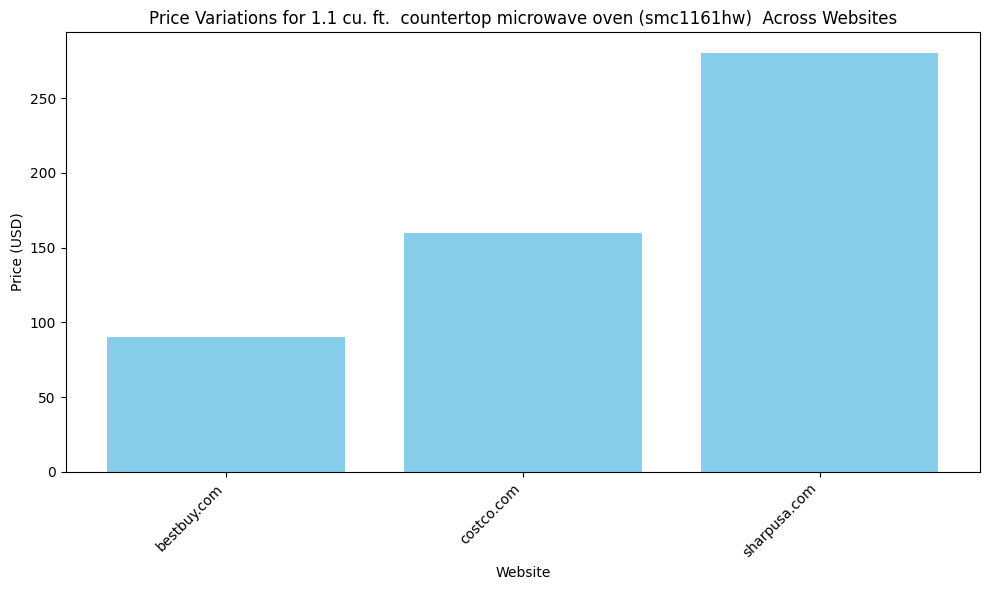


Average promotion par group:
               category         promotion  count
123               ovens   Sale ends Feb 5     17
5    appliance-packages   Sale ends Jan 8     22
3    appliance-packages   Sale ends Feb 5     26
73              laundry  Sale ends Jan 29     28
70              laundry     On Sale Today     36
29          dishwashers   Sale ends Feb 5     42
1    appliance-packages     On Sale Today     44
71              laundry   Sale ends Feb 5     51
161       refrigerators   January Savings    103
6            appliances       Flash Sale!    200


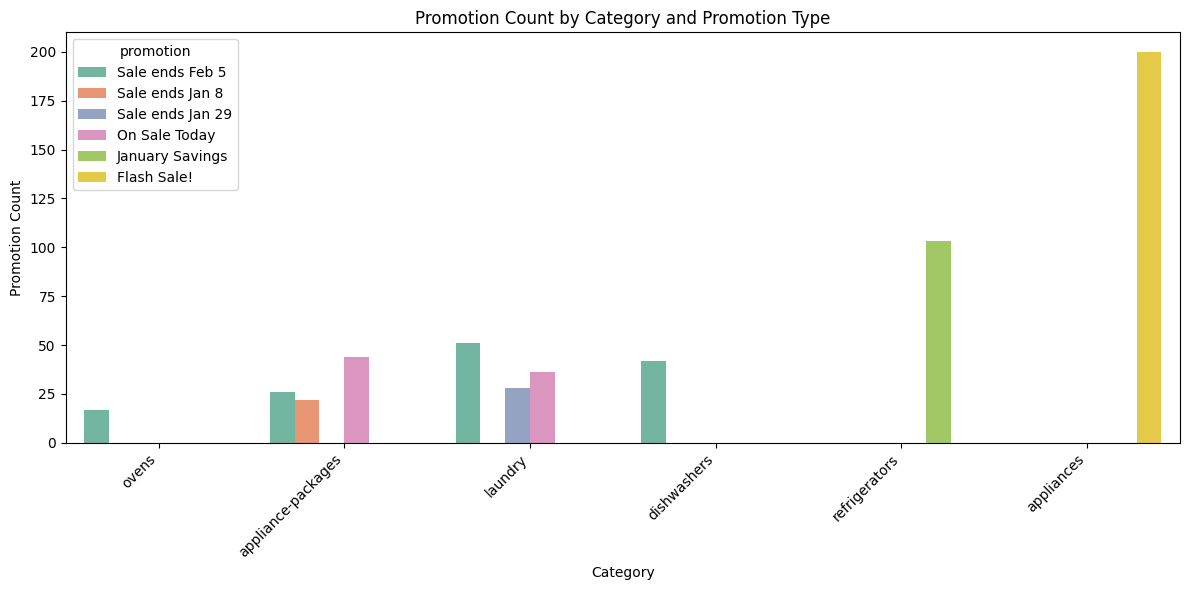


Top Products by Occurrence:
                                                 nom       website      min  \
0  Insignia™ - 17 Cu. Ft. Garage Ready Convertibl...   bestbuy.com   599.99   
1  Sharp Plasmacluster Ion Air Purifier with True...  sharpusa.com   129.99   
2   European Convection Built-In Single Wall Oven...  sharpusa.com  1299.99   
3  Sharp French 4-Door Counter-Depth Refrigerator...  sharpusa.com  1599.99   
4  Sharp French 4-Door Counter-Depth Refrigerator...  sharpusa.com  2599.99   
5  Sharp Plasmacluster Ion Air Purifier with True...  sharpusa.com   349.99   
6  24 in.  European Convection Built-In Single Wa...  sharpusa.com  1299.99   
7  Sharp Smart Plasmacluster Ion Air Purifier wit...  sharpusa.com   399.99   
8  Sharp Plasmacluster Ion Air Purifier with True...  sharpusa.com   249.99   
9  Sharp Smart Plasmacluster Ion Air Purifier wit...  sharpusa.com   469.99   

          mean      max  count  
0   607.565758   799.99     33  
1   149.220769   179.99     26  
2 

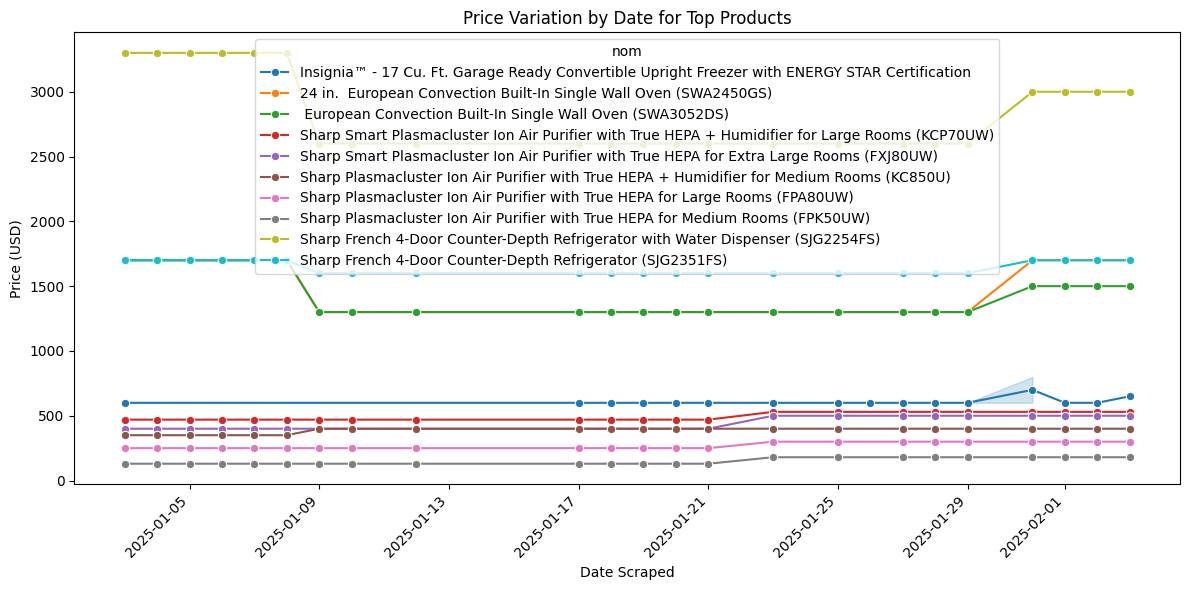


Prices by sites:
                    website     min         mean       max
1  applianceworldonline.com  165.00   384.196761    949.00
7              sharpusa.com   84.99   712.266640   3299.99
3                costco.com   14.97   977.512230  10499.99
4                    lg.com  299.00  1158.200000   3599.00
2               bestbuy.com   59.99  1250.629486  10099.00
5               samsung.com  299.00  1300.458333   2699.00
6                 sears.com    7.52  1321.798105   9836.99
0      airportappliance.com  197.00  1456.156250   3299.00
8          us-appliance.com  398.00  2258.797779  14999.00


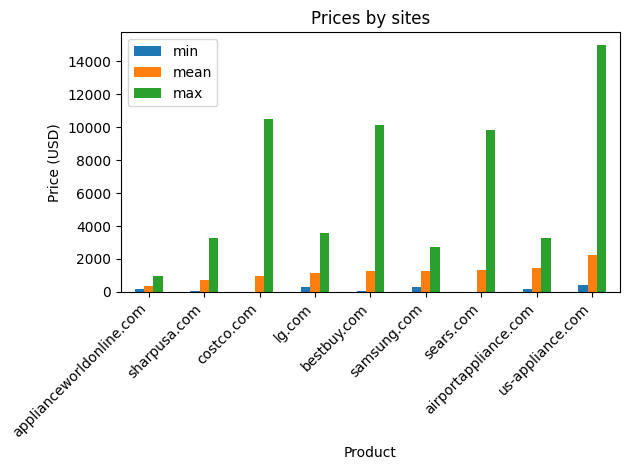

In [12]:
# Main execution
if __name__ == "__main__":
    old_data = pd.read_csv("Electromenagerscleaned_data.csv")  # Read the existing data from the file
    # Concatenate the cleaned data to the old data
    df_cleaned = old_data

    # Analyze data and visualize
    # Get the top product and price variations
    top_product, price_variations = analyse_get_top_product_price_variation(df_cleaned)
    
    print(f"Top Product: {top_product}")
    print("Price variations by website:")
    print(price_variations)
    # Plot the price variations
    visualisation_plot_price_variations(price_variations, top_product)
    
    
    print("\r\nAverage promotion par group:")
    print(analyse_promotions_par_categorie(df_cleaned))
    visualisation_plot_promotions(analyse_promotions_par_categorie(df_cleaned), 
        title="Promotion Count by Category and Promotion Type", 
        xlabel="Category", 
        ylabel="Promotion Count")
    
    
    products_by_date = analyse_group_by_nom_website_date(df_cleaned)
    print("\r\nTop Products by Occurrence:")
    print(products_by_date)
    # Plot price variations by date for the top products
    visualisation_plot_price_variations_by_date(df_cleaned, products_by_date)
    
    
    print("\r\nPrices by sites:")
    print(analyse_data_in_same_site_grouped_sites(df_cleaned))
    visualisation_plot_data(analyse_data_in_same_site_grouped_sites(df_cleaned), "Prices by sites", "Product", "Price (USD)", "website", ["min", "mean", "max"])